In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import sys
import os

# 把项目根目录加到 Python 路径，这样可以 import src/ 里的模块
sys.path.append(os.path.abspath('..'))

from src.db_utils import get_engine, query_to_df, df_to_table

# Set pandas display option
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# ============================================================
# Generate synthetic seed data based on real Canadian rent statistics
# Source basis: CMHC Rental Market Survey & StatCan Table 34-10-0133-01
# Note: These datas will be replaced with real CMHC API data in Day 2
# ============================================================

np.random.seed(42)  # fix the seed to make sure the result can be conducted

# 5 main cities and their details (based on CMHC)
cities_info = {
    'Toronto':    {'province': 'Ontario',          'province_code': 'ON', 'base_rent_2bed': 2800, 'pop': 2930000, 'lat': 43.6532, 'lon': -79.3832},
    'Vancouver':  {'province': 'British Columbia', 'province_code': 'BC', 'base_rent_2bed': 3100, 'pop': 675000,  'lat': 49.2827, 'lon': -123.1207},
    'Montreal':   {'province': 'Quebec',           'province_code': 'QC', 'base_rent_2bed': 1700, 'pop': 1780000, 'lat': 45.5017, 'lon': -73.5673},
    'Ottawa':     {'province': 'Ontario',          'province_code': 'ON', 'base_rent_2bed': 2050, 'pop': 1010000, 'lat': 45.4215, 'lon': -75.6972},
    'Calgary':    {'province': 'Alberta',          'province_code': 'AB', 'base_rent_2bed': 1650, 'pop': 1336000, 'lat': 51.0447, 'lon': -114.0719},
}

# Property Type and the price coefficient
property_types = {
    'Bachelor':  0.65,   # single apartment
    '1-Bedroom': 0.80,
    '2-Bedroom': 1.00,
    '3-Bedroom': 1.25,
}

# Produce all years, months from 2015-01 to 2024-12
date_range = pd.date_range(start='2015-01-01', end='2024-12-01', freq='MS')

# collect all the datas
records = []

for city, info in cities_info.items():
    for date in date_range:
        # Simulate the inflation + trends
        years_from_2015 = (date.year - 2015) + (date.month - 1) / 12

        # BC policy Impact
        if info['province_code'] == 'BC' and date.year >= 2018:
            growth_rate = 1.05 ** ((2018 - 2015)) * 1.025 ** (years_from_2015 - 3)
        else:
            growth_rate = 1.05 ** years_from_2015

        # Seasonal Factor
        seasonal = 1 + 0.02 * np.sin(2 * np.pi * date.month / 12)

        for ptype, multiplier in property_types.items():
            base = info['base_rent_2bed'] * multiplier * growth_rate * seasonal
            #  Noise ±3%
            noise = np.random.normal(1.0, 0.03)
            rent = round(base * noise, 2)

            # Simulate the vacancy
            if info['province_code'] == 'BC' and date.year >= 2018:
                vacancy = round(np.random.uniform(2.5, 4.5), 2)
            else:
                vacancy = round(np.random.uniform(1.5, 3.5), 2)

            records.append({
                'city_name': city,
                'province': info['province'],
                'province_code': info['province_code'],
                'population': info['pop'],
                'latitude': info['lat'],
                'longitude': info['lon'],
                'year': date.year,
                'month': date.month,
                'property_type': ptype,
                'avg_rent_cad': rent,
                'vacancy_rate': vacancy,
                'data_source': 'CMHC_seed'
            })


df_raw = pd.DataFrame(records)

print(f"✓ Generated {len(df_raw):,} rows")
print(f"  Cities: {df_raw['city_name'].nunique()}")
print(f"  Date range: {df_raw['year'].min()}–{df_raw['year'].max()}")
print(f"  Property types: {df_raw['property_type'].nunique()}")

df_raw.head()

✓ Generated 2,400 rows
  Cities: 5
  Date range: 2015–2024
  Property types: 4


,city_name,province,province_code,population,latitude,longitude,year,month,property_type,avg_rent_cad,vacancy_rate,data_source
0,Toronto,Ontario,ON,2930000,43.6532,-79.3832,2015,1,Bachelor,1865.59,2.96,CMHC_seed
1,Toronto,Ontario,ON,2930000,43.6532,-79.3832,2015,1,1-Bedroom,2253.02,2.70,CMHC_seed
2,Toronto,Ontario,ON,2930000,43.6532,-79.3832,2015,1,2-Bedroom,2808.13,1.62,CMHC_seed
3,Toronto,Ontario,ON,2930000,43.6532,-79.3832,2015,1,3-Bedroom,3510.17,3.23,CMHC_seed
4,Toronto,Ontario,ON,2930000,43.6532,-79.3832,2015,2,Bachelor,1947.14,1.54,CMHC_seed


In [3]:
# Save to data/raw/ file
output_path = '../data/raw/canada_rent_seed.csv'
df_raw.to_csv(output_path, index=False)
print(f"✓ Saved to {output_path}")

✓ Saved to ../data/raw/canada_rent_seed.csv


In [4]:
# ============================================================
# DATA Overview - Explore the data
# ============================================================

print("=" * 60)
print("BASIC INFO")
print("=" * 60)
df_raw.info()

print("\n" + "=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)
print(df_raw.describe())

print("\n" + "=" * 60)
print("MISSING VALUES CHECK")
print("=" * 60)
print(df_raw.isnull().sum())

print("\n" + "=" * 60)
print("DUPLICATES CHECK")
print("=" * 60)
print(f"Total duplicate rows: {df_raw.duplicated().sum()}")

BASIC INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   city_name      2400 non-null   object 
 1   province       2400 non-null   object 
 2   province_code  2400 non-null   object 
 3   population     2400 non-null   int64  
 4   latitude       2400 non-null   float64
 5   longitude      2400 non-null   float64
 6   year           2400 non-null   int64  
 7   month          2400 non-null   int64  
 8   property_type  2400 non-null   object 
 9   avg_rent_cad   2400 non-null   float64
 10  vacancy_rate   2400 non-null   float64
 11  data_source    2400 non-null   object 
dtypes: float64(4), int64(3), object(5)
memory usage: 225.1+ KB

STATISTICAL SUMMARY
         population     latitude    longitude        year        month  avg_rent_cad  vacancy_rate
count  2.400000e+03  2400.000000  2400.000000  2400.00000  2400.000000   2400.0000

F:\canada-housing-affordability\.venv\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


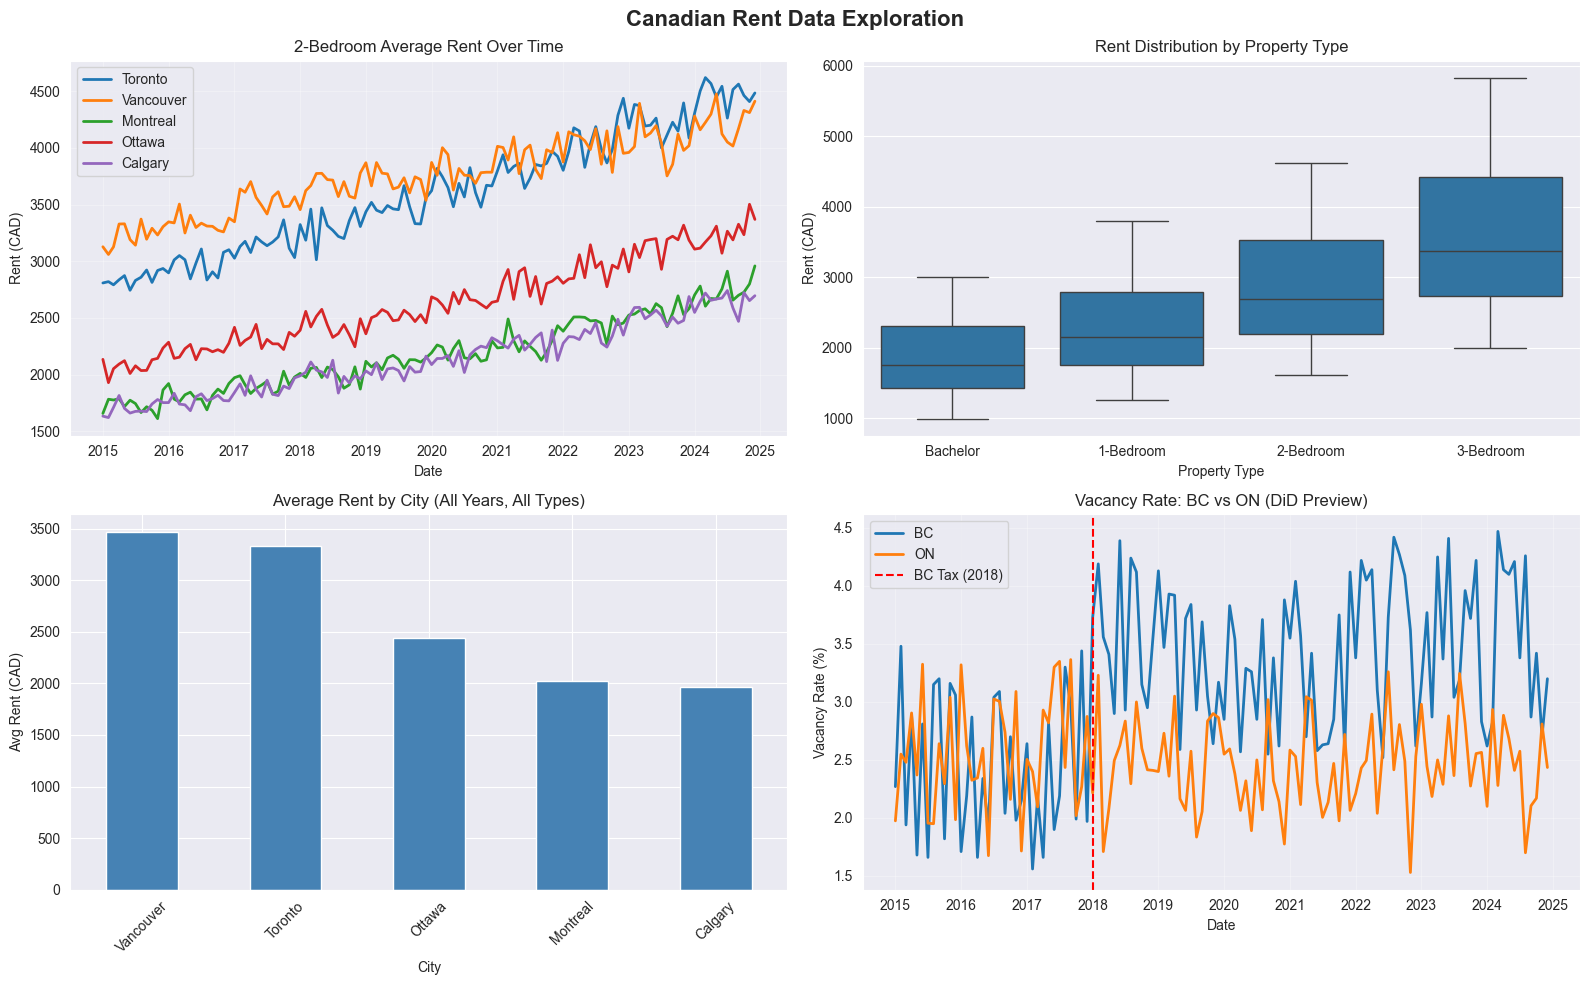

✓ Visualization complete


In [5]:
# ============================================================
# Data VISUAL EXPLORATION
# ============================================================

# Set the canvas
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Canadian Rent Data Exploration', fontsize=16, fontweight='bold')

# P1：Changes of the rent of 2-bedroom with time per city  各城市 2-bedroom 租金随时间变化
ax1 = axes[0, 0]
df_2bed = df_raw[df_raw['property_type'] == '2-Bedroom'].copy()
df_2bed['date'] = pd.to_datetime(df_2bed[['year', 'month']].assign(day=1))

for city in df_2bed['city_name'].unique():
    city_data = df_2bed[df_2bed['city_name'] == city]
    ax1.plot(city_data['date'], city_data['avg_rent_cad'], label=city, linewidth=2)

ax1.set_title('2-Bedroom Average Rent Over Time')
ax1.set_xlabel('Date')
ax1.set_ylabel('Rent (CAD)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# P2: Rental Distribution by Housing Type(boxplot)
ax2 = axes[0, 1]
sns.boxplot(data=df_raw, x='property_type', y='avg_rent_cad',
            order=['Bachelor', '1-Bedroom', '2-Bedroom', '3-Bedroom'], ax=ax2)
ax2.set_title('Rent Distribution by Property Type')
ax2.set_xlabel('Property Type')
ax2.set_ylabel('Rent (CAD)')

# 图 3：各城市平均租金对比（柱状图）
ax3 = axes[1, 0]
city_avg = df_raw.groupby('city_name')['avg_rent_cad'].mean().sort_values(ascending=False)
city_avg.plot(kind='bar', ax=ax3, color='steelblue')
ax3.set_title('Average Rent by City (All Years, All Types)')
ax3.set_xlabel('City')
ax3.set_ylabel('Avg Rent (CAD)')
ax3.tick_params(axis='x', rotation=45)

# 图 4：BC 省 vs Ontario 空置率对比（这是 DiD 的伏笔！）
ax4 = axes[1, 1]
df_2bed_grouped = df_2bed.groupby(['date', 'province_code'])['vacancy_rate'].mean().reset_index()
for prov in ['BC', 'ON']:
    prov_data = df_2bed_grouped[df_2bed_grouped['province_code'] == prov]
    ax4.plot(prov_data['date'], prov_data['vacancy_rate'], label=prov, linewidth=2)

ax4.axvline(pd.to_datetime('2018-01-01'), color='red', linestyle='--', label='BC Tax (2018)')
ax4.set_title('Vacancy Rate: BC vs ON (DiD Preview)')
ax4.set_xlabel('Date')
ax4.set_ylabel('Vacancy Rate (%)')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Visualization complete")

In [4]:
# ============================================================
# TRANSFORM - Prepare the real data for PostgreSQL
# ============================================================

# Step 1 Prepare dim_city table
dim_city = df_raw[['city_name', 'province', 'province_code',
                   'population', 'latitude', 'longitude']].drop_duplicates().reset_index(drop=True)
print(f" dim_city prepared: {len(dim_city)} rows")
print(dim_city)

# Step 2 Prepare dim_time tabe
dim_time = df_raw[['year', 'month']].drop_duplicates().reset_index(drop=True)
dim_time['quarter'] = ((dim_time['month'] - 1) // 3) + 1
dim_time['year_month_label'] = dim_time['year'].astype(str) + '-' + dim_time['month'].astype(str).str.zfill(2)
dim_time = dim_time.sort_values(['year', 'month']).reset_index(drop=True)
print(f"\n dim_time prepared: {len(dim_time)} rows")
print(dim_time.head())

# Step 3 Prepare dim_property_type table
property_descriptions = {
    'Bachelor':  'Studio apartment with no separate bedroom',
    '1-Bedroom': 'Apartment with one separate bedroom',
    '2-Bedroom': 'Apartment with two separate bedrooms',
    '3-Bedroom': 'Apartment with three or more bedrooms',
}
dim_property_type = pd.DataFrame({
    'type_name': list(property_descriptions.keys()),
    'description': list(property_descriptions.values())
})
print(f"\n dim_property_type prepared: {len(dim_property_type)} rows")
print(dim_property_type)

 dim_city prepared: 5 rows
   city_name          province province_code  population  latitude  longitude
0    Toronto           Ontario            ON     2930000   43.6532   -79.3832
1  Vancouver  British Columbia            BC      675000   49.2827  -123.1207
2   Montreal            Quebec            QC     1780000   45.5017   -73.5673
3     Ottawa           Ontario            ON     1010000   45.4215   -75.6972
4    Calgary           Alberta            AB     1336000   51.0447  -114.0719

 dim_time prepared: 120 rows
   year  month  quarter year_month_label
0  2015      1        1          2015-01
1  2015      2        1          2015-02
2  2015      3        1          2015-03
3  2015      4        2          2015-04
4  2015      5        2          2015-05

 dim_property_type prepared: 4 rows
   type_name                                description
0   Bachelor  Studio apartment with no separate bedroom
1  1-Bedroom        Apartment with one separate bedroom
2  2-Bedroom       Apart

In [5]:
# ============================================================
# LOAD - Load dim tables to PostgreSQL
# ============================================================

from sqlalchemy import text

engine = get_engine()

# Clear the old table if it exists in order to restart the process
with engine.begin() as conn: conn.execute(text("TRUNCATE TABLE fact_rent, dim_city, dim_time, dim_property_type RESTART IDENTITY CASCADE;"))
print("✓ Tables truncated, ready to load")

# Load dim_city
dim_city.to_sql('dim_city', engine, if_exists='append', index=False)
print(f"✓ Loaded {len(dim_city)} rows to dim_city")

# Load dim_time
dim_time.to_sql('dim_time', engine, if_exists='append', index=False)
print(f"✓ Loaded {len(dim_time)} rows to dim_time")

# Load dim_property_type
dim_property_type.to_sql('dim_property_type', engine, if_exists='append', index=False)
print(f"✓ Loaded {len(dim_property_type)} rows to dim_property_type")

print("\n✓ All dimension tables loaded successfully")

✓ Tables truncated, ready to load
✓ Loaded 5 rows to dim_city
✓ Loaded 120 rows to dim_time
✓ Loaded 4 rows to dim_property_type

✓ All dimension tables loaded successfully


In [6]:
# ============================================================
# Read the ID mapping of dim tables from PostgreSql
# ============================================================

# Use SQL query to check the ID mapping of dim_city
city_mapping = query_to_df("""
    SELECT city_id, city_name, province_code
    FROM dim_city
""")
print("✓ City ID mapping:")
print(city_mapping)

# Check the ID mapping of time
time_mapping = query_to_df("""
    SELECT time_id, year, month
    FROM dim_time
""")
print(f"\n✓ Time ID mapping: {len(time_mapping)} rows (showing first 5)")
print(time_mapping.head())

# Check the ID mapping of property
property_mapping = query_to_df("""
    SELECT property_type_id, type_name
    FROM dim_property_type
""")
print("\n✓ Property type ID mapping:")
print(property_mapping)

✓ City ID mapping:
   city_id  city_name province_code
0        1    Toronto            ON
1        2  Vancouver            BC
2        3   Montreal            QC
3        4     Ottawa            ON
4        5    Calgary            AB

✓ Time ID mapping: 120 rows (showing first 5)
   time_id  year  month
0        1  2015      1
1        2  2015      2
2        3  2015      3
3        4  2015      4
4        5  2015      5

✓ Property type ID mapping:
   property_type_id  type_name
0                 1   Bachelor
1                 2  1-Bedroom
2                 3  2-Bedroom
3                 4  3-Bedroom


In [9]:
# ============================================================
# 构建 fact_rent: 把业务键（name）替换成代理键（id）
# ============================================================

# 从 df_raw 开始，逐步 merge 各个 dim 的 id

# Merge 1: 加上 city_id
fact_rent = df_raw.merge(
    city_mapping,
    on=['city_name', 'province_code'],
    how='left'
)
print(f"After merging city_id: {len(fact_rent)} rows, {fact_rent['city_id'].isnull().sum()} unmatched")

# Merge 2: 加上 time_id
fact_rent = fact_rent.merge(
    time_mapping,
    on=['year', 'month'],
    how='left'
)
print(f"After merging time_id: {len(fact_rent)} rows, {fact_rent['time_id'].isnull().sum()} unmatched")

# Merge 3: 加上 property_type_id
fact_rent = fact_rent.merge(
    property_mapping,
    left_on='property_type',
    right_on='type_name',
    how='left'
)
print(f"After merging property_type_id: {len(fact_rent)} rows, {fact_rent['property_type_id'].isnull().sum()} unmatched")

# 只保留 fact_rent 表需要的列
fact_rent_final = fact_rent[[
    'city_id', 'time_id', 'property_type_id',
    'avg_rent_cad', 'vacancy_rate', 'data_source'
]].copy()

print(f"\n✓ fact_rent_final shape: {fact_rent_final.shape}")
print(fact_rent_final.head())

After merging city_id: 2400 rows, 0 unmatched
After merging time_id: 2400 rows, 0 unmatched
After merging property_type_id: 2400 rows, 0 unmatched

✓ fact_rent_final shape: (2400, 6)
   city_id  time_id  property_type_id  avg_rent_cad  vacancy_rate data_source
0        1        1                 1       1865.59          2.96   CMHC_seed
1        1        1                 2       2253.02          2.70   CMHC_seed
2        1        1                 3       2808.13          1.62   CMHC_seed
3        1        1                 4       3510.17          3.23   CMHC_seed
4        1        2                 1       1947.14          1.54   CMHC_seed


In [10]:
# ============================================================
# 最后一步 LOAD：写入 fact_rent 表
# ============================================================

fact_rent_final.to_sql('fact_rent', engine, if_exists='append', index=False)
print(f"✓ Loaded {len(fact_rent_final):,} rows to fact_rent")

# 立刻验证一下入库行数
verify = query_to_df("SELECT COUNT(*) AS row_count FROM fact_rent")
print(f"\n✓ Database verification:")
print(verify)

✓ Loaded 2,400 rows to fact_rent

✓ Database verification:
   row_count
0       2400


In [11]:
# ============================================================
# 验证 + 第一个业务查询
# 用 JOIN 把 fact 和 dim 表串起来
# ============================================================

# 验证 1：每个城市的记录数（应该都是 480）
print("=" * 60)
print("VERIFY 1: Records per city")
print("=" * 60)
result1 = query_to_df("""
    SELECT
        c.city_name,
        c.province_code,
        COUNT(*) AS record_count
    FROM fact_rent f
    JOIN dim_city c ON f.city_id = c.city_id
    GROUP BY c.city_name, c.province_code
    ORDER BY c.city_name;
""")
print(result1)

# 验证 2：第一个真正的业务查询——2024 年各城市 2-bedroom 平均租金
print("\n" + "=" * 60)
print("BUSINESS QUERY: Avg 2-Bedroom Rent in 2024")
print("=" * 60)
result2 = query_to_df("""
    SELECT
        c.city_name,
        c.province_code,
        ROUND(AVG(f.avg_rent_cad)::numeric, 2) AS avg_rent_2024,
        ROUND(AVG(f.vacancy_rate)::numeric, 2) AS avg_vacancy_2024
    FROM fact_rent f
    JOIN dim_city c           ON f.city_id = c.city_id
    JOIN dim_time t           ON f.time_id = t.time_id
    JOIN dim_property_type p  ON f.property_type_id = p.property_type_id
    WHERE t.year = 2024
      AND p.type_name = '2-Bedroom'
    GROUP BY c.city_name, c.province_code
    ORDER BY avg_rent_2024 DESC;
""")
print(result2)

# 验证 3：BC vs ON 在 2017（政策前）和 2019（政策后）的对比 —— DiD 预热！
print("\n" + "=" * 60)
print("DiD PREVIEW: BC vs ON Rent Change (2017 → 2019)")
print("=" * 60)
result3 = query_to_df("""
    SELECT
        c.province_code,
        t.year,
        ROUND(AVG(f.avg_rent_cad)::numeric, 2) AS avg_rent
    FROM fact_rent f
    JOIN dim_city c ON f.city_id = c.city_id
    JOIN dim_time t ON f.time_id = t.time_id
    JOIN dim_property_type p ON f.property_type_id = p.property_type_id
    WHERE c.province_code IN ('BC', 'ON')
      AND t.year IN (2017, 2019)
      AND p.type_name = '2-Bedroom'
    GROUP BY c.province_code, t.year
    ORDER BY c.province_code, t.year;
""")
print(result3)
print("\n💡 Notice: BC's rent growth from 2017→2019 should be SLOWER than ON's")


VERIFY 1: Records per city
   city_name province_code  record_count
0    Calgary            AB           480
1   Montreal            QC           480
2     Ottawa            ON           480
3    Toronto            ON           480
4  Vancouver            BC           480

BUSINESS QUERY: Avg 2-Bedroom Rent in 2024
   city_name province_code  avg_rent_2024  avg_vacancy_2024
0    Toronto            ON        4474.23              2.24
1  Vancouver            BC        4238.23              3.52
2     Ottawa            ON        3240.17              2.61
3   Montreal            QC        2744.26              2.49
4    Calgary            AB        2648.18              2.69

DiD PREVIEW: BC vs ON Rent Change (2017 → 2019)
  province_code  year  avg_rent
0            BC  2017   3540.55
1            BC  2019   3715.82
2            ON  2017   2732.70
3            ON  2019   2984.33

💡 Notice: BC's rent growth from 2017→2019 should be SLOWER than ON's


---

# Day 2: Real Canadian Data from Statistics Canada API

# In Day 1, we used synthetic seed data to validate the ETL pipeline.
# In Day 2, we replace it with real data from Statistics Canada's
# Web Data Service API.

# **Data sources:**
# - Statistics Canada Table 18-10-0205-01: New housing price index
# - Statistics Canada Table 34-10-0133-01: Canadian rental statistics

# **Why API over manual download:**
# - Reproducibility: pipeline can refresh automatically
# - Time coverage: full history (2010-2024) available
# - Avoids inconsistent Excel formatting

In [12]:
# ============================================================
# Day 2 - Step 1: Test connection to Statistics Canada API
# ============================================================

import requests
import json

# StatCan WDS API base URL
BASE_URL = "https://www150.statcan.gc.ca/t1/wds/rest"

# 先做最简单的测试：拿到 API 的元数据，确认我们能连上
# Table 34-10-0133-01 = Canadian rental statistics
# StatCan 内部 PID（产品 ID）格式：把 4-2-2 转成 8 位整数
table_pid = "34100133"  # 对应 Table 34-10-0133-01

# 拼接 URL：拿这个 table 的元数据
url = f"{BASE_URL}/getCubeMetadata"

# StatCan API 用 POST 请求 + JSON body
payload = [{"productId": int(table_pid)}]
headers = {"Content-Type": "application/json"}

print(f"Calling: {url}")
print(f"Payload: {payload}")

# 发送请求，超时 30 秒
try:
    response = requests.post(url, json=payload, headers=headers, timeout=30)
    print(f"\n✓ Status code: {response.status_code}")

    if response.status_code == 200:
        data = response.json()
        print(f"✓ Response received")
        print(f"  Type: {type(data)}")
        print(f"  Length: {len(data) if isinstance(data, list) else 'N/A'}")

        # 看看返回的第一个元素长什么样
        if isinstance(data, list) and len(data) > 0:
            first_item = data[0]
            print(f"\n  First item keys: {list(first_item.keys())[:10]}")
    else:
        print(f"✗ Request failed: {response.text[:300]}")
except requests.exceptions.RequestException as e:
    print(f"✗ Request error: {e}")

Calling: https://www150.statcan.gc.ca/t1/wds/rest/getCubeMetadata
Payload: [{'productId': 34100133}]

✓ Status code: 200
✓ Response received
  Type: <class 'list'>
  Length: 1

  First item keys: ['status', 'object']


In [13]:
# ============================================================
# Day 2 - Step 2: Explore the metadata
# 看看这个 table 包含什么维度、有多少行、覆盖什么时间范围
# ============================================================

# 提取 metadata（嵌套很深，逐层拨开）
metadata = data[0]["object"]

print("=" * 60)
print("TABLE METADATA OVERVIEW")
print("=" * 60)
print(f"Table title (EN): {metadata.get('cubeTitleEn', 'N/A')}")
print(f"Table title (FR): {metadata.get('cubeTitleFr', 'N/A')}")
print(f"Start date:       {metadata.get('cubeStartDate', 'N/A')}")
print(f"End date:         {metadata.get('cubeEndDate', 'N/A')}")
print(f"Frequency:        {metadata.get('frequencyCode', 'N/A')}")
print(f"Total dimensions: {len(metadata.get('dimension', []))}")

# 看看维度（dimensions）有哪些 —— 这决定了我们能怎么"切"数据
print("\n" + "=" * 60)
print("DIMENSIONS (这些是数据的'维度')")
print("=" * 60)
for i, dim in enumerate(metadata.get('dimension', []), 1):
    name_en = dim.get('dimensionNameEn', 'N/A')
    member_count = len(dim.get('member', []))
    print(f"{i}. {name_en} (含 {member_count} 个值)")

TABLE METADATA OVERVIEW
Table title (EN): Canada Mortgage and Housing Corporation, average rents for areas with a population of 10,000 and over
Table title (FR): Société canadienne d'hypothèques et de logement, loyers moyens pour les régions de 10 000 habitants et plus
Start date:       1987-01-01
End date:         2025-01-01
Frequency:        12
Total dimensions: 3

DIMENSIONS (这些是数据的'维度')
1. Geography (含 247 个值)
2. Type of structure (含 4 个值)
3. Type of unit (含 4 个值)


In [14]:
# ============================================================
# Day 2 - Step 3: Drill into each dimension's members
# 看看每个维度具体有哪些值
# ============================================================

dimensions = metadata.get('dimension', [])

# 1. Geography 维度（247 个值，太多了，只看前 20 个 + 搜索我们关心的城市）
print("=" * 60)
print("DIMENSION 1: Geography (showing first 15 members)")
print("=" * 60)
geo_dim = dimensions[0]
geo_members = geo_dim.get('member', [])
for m in geo_members[:15]:
    print(f"  ID: {m['memberId']:5d}  |  {m['memberNameEn']}")

print(f"\n... and {len(geo_members) - 15} more")

# 搜索我们项目需要的 5 个城市
print("\n" + "=" * 60)
print("Searching for our target cities:")
print("=" * 60)
target_cities = ['Vancouver', 'Toronto', 'Montréal', 'Ottawa', 'Calgary']
for city in target_cities:
    matches = [m for m in geo_members if city.lower() in m['memberNameEn'].lower()]
    print(f"\n'{city}' matches:")
    for m in matches[:5]:  # 只显示前 5 个匹配
        print(f"  ID: {m['memberId']:5d}  |  {m['memberNameEn']}")

# 2. Type of structure 维度（4 个值）
print("\n" + "=" * 60)
print("DIMENSION 2: Type of structure (all 4 members)")
print("=" * 60)
structure_dim = dimensions[1]
for m in structure_dim.get('member', []):
    print(f"  ID: {m['memberId']}  |  {m['memberNameEn']}")

# 3. Type of unit 维度（4 个值）—— 应该对应房型
print("\n" + "=" * 60)
print("DIMENSION 3: Type of unit (all 4 members)")
print("=" * 60)
unit_dim = dimensions[2]
for m in unit_dim.get('member', []):
    print(f"  ID: {m['memberId']}  |  {m['memberNameEn']}")

DIMENSION 1: Geography (showing first 15 members)
  ID:   192  |  Bay Roberts, Newfoundland and Labrador
  ID:     1  |  Carbonear, Newfoundland and Labrador
  ID:     2  |  Corner Brook, Newfoundland and Labrador
  ID:     3  |  Gander, Newfoundland and Labrador
  ID:     4  |  Grand Falls-Windsor, Newfoundland and Labrador
  ID:     5  |  Labrador City, Newfoundland and Labrador
  ID:     6  |  St. John's, Newfoundland and Labrador
  ID:     7  |  Charlottetown, Prince Edward Island
  ID:     8  |  Summerside, Prince Edward Island
  ID:     9  |  Cape Breton, Nova Scotia
  ID:   208  |  Chester, Nova Scotia
  ID:   209  |  East Hants, Nova Scotia
  ID:    10  |  Halifax, Nova Scotia
  ID:    11  |  Kentville, Nova Scotia
  ID:    12  |  Kentville, Nova Scotia

... and 232 more

Searching for our target cities:

'Vancouver' matches:
  ID:   184  |  Vancouver, British Columbia

'Toronto' matches:
  ID:   125  |  Toronto, Ontario

'Montréal' matches:
  ID:    46  |  Montréal, Quebec

'O

In [15]:
# ============================================================
# Day 2 - Step 4: Define query parameters
# 把我们要的 IDs 整理好，准备发查询
# ============================================================

# 5 个目标城市的 Geography ID
TARGET_CITIES = {
    184: ('Vancouver',  'British Columbia',  'BC'),
    125: ('Toronto',    'Ontario',           'ON'),
    46:  ('Montréal',   'Quebec',            'QC'),
    106: ('Ottawa',     'Ontario',           'ON'),  # Ontario part only
    146: ('Calgary',    'Alberta',           'AB'),
}

# Type of structure: 用最广覆盖的 ID 3
STRUCTURE_ID = 3  # Row and apartment structures of three units and over

# Type of unit: 4 种房型全要
UNIT_TYPES = {
    1: 'Bachelor',
    2: '1-Bedroom',
    3: '2-Bedroom',
    4: '3-Bedroom',
}

# 时间范围（年度数据，所以是年份）
START_YEAR = 2010   # 政策前 8 年
END_YEAR   = 2024   # 政策后 6 年（2025 数据可能还没全）

print(f"Query plan:")
print(f"  Cities:    {len(TARGET_CITIES)} ({list(c[0] for c in TARGET_CITIES.values())})")
print(f"  Structure: ID {STRUCTURE_ID}")
print(f"  Units:     {list(UNIT_TYPES.values())}")
print(f"  Years:     {START_YEAR} - {END_YEAR}")
print(f"\nExpected rows: {len(TARGET_CITIES)} cities × {len(UNIT_TYPES)} units × {END_YEAR-START_YEAR+1} years = {len(TARGET_CITIES) * len(UNIT_TYPES) * (END_YEAR-START_YEAR+1)} rows")

Query plan:
  Cities:    5 (['Vancouver', 'Toronto', 'Montréal', 'Ottawa', 'Calgary'])
  Structure: ID 3
  Units:     ['Bachelor', '1-Bedroom', '2-Bedroom', '3-Bedroom']
  Years:     2010 - 2024

Expected rows: 5 cities × 4 units × 15 years = 300 rows


In [16]:
# ============================================================
# Day 2 - Step 5: Fetch real data from StatCan API
# 用循环拉取所有组合的真实数据
# ============================================================

import time

def fetch_rent_data(geo_id, structure_id, unit_id, n_periods=20):
    """
    从 StatCan API 拉取一个具体维度组合的最近 N 年数据。

    Parameters
    ----------
    geo_id : int      城市 ID（如 184 = Vancouver）
    structure_id : int 结构 ID（我们用 3）
    unit_id : int     房型 ID（1-4）
    n_periods : int   要最近多少个年份

    Returns
    -------
    list of dict     每条记录含 year, value 等
    """
    url = f"{BASE_URL}/getDataFromCubePidCoordAndLatestNPeriods"

    # StatCan API 的 coordinate 格式：3 个维度的 ID 用 "." 拼接
    # 因为这个 table 只有 3 个维度（Geography, Structure, Unit）
    # 所以 coordinate 是 "geo_id.structure_id.unit_id"
    # 后面补 0（API 要求总共 10 个位置，缺的填 0）
    coordinate = f"{geo_id}.{structure_id}.{unit_id}.0.0.0.0.0.0.0"

    payload = [{
        "productId": int(table_pid),
        "coordinate": coordinate,
        "latestN": n_periods
    }]

    response = requests.post(url, json=payload, headers=headers, timeout=30)

    if response.status_code != 200:
        print(f"  ✗ Failed for geo={geo_id}, unit={unit_id}: {response.status_code}")
        return []

    data = response.json()

    # 检查 API 自己的状态
    if data[0].get('status') != 'SUCCESS':
        print(f"  ✗ API error for geo={geo_id}, unit={unit_id}: {data[0].get('status')}")
        return []

    # 提取真正的数据点
    return data[0].get('object', {}).get('vectorDataPoint', [])


# ============================================================
# 循环抓取所有 5 城市 × 4 房型 = 20 个组合
# ============================================================
print("Starting API fetch loop...")
print("=" * 60)

all_records = []

for geo_id, (city_name, province, prov_code) in TARGET_CITIES.items():
    for unit_id, unit_name in UNIT_TYPES.items():
        print(f"Fetching: {city_name:12s} | {unit_name:12s}", end=" ")

        data_points = fetch_rent_data(geo_id, STRUCTURE_ID, unit_id, n_periods=20)

        # 把每个数据点整理成一条记录
        for dp in data_points:
            all_records.append({
                'geo_id':         geo_id,
                'city_name':      city_name,
                'province':       province,
                'province_code':  prov_code,
                'unit_id':        unit_id,
                'unit_type':      unit_name,
                'reference_period': dp.get('refPer'),    # 年份
                'avg_rent_cad':   dp.get('value'),       # 实际租金
                'status':         dp.get('symbolCode'),  # 数据状态码
            })

        print(f"→ {len(data_points)} records")

        # 礼貌性间隔，避免被限流
        time.sleep(0.3)

print("=" * 60)
print(f"\n✓ Total records collected: {len(all_records)}")

Starting API fetch loop...
Fetching: Vancouver    | Bachelor     → 20 records
Fetching: Vancouver    | 1-Bedroom    → 20 records
Fetching: Vancouver    | 2-Bedroom    → 20 records
Fetching: Vancouver    | 3-Bedroom    → 20 records
Fetching: Toronto      | Bachelor     → 20 records
Fetching: Toronto      | 1-Bedroom    → 20 records
Fetching: Toronto      | 2-Bedroom    → 20 records
Fetching: Toronto      | 3-Bedroom    → 20 records
Fetching: Montréal     | Bachelor     → 20 records
Fetching: Montréal     | 1-Bedroom    → 20 records
Fetching: Montréal     | 2-Bedroom    → 20 records
Fetching: Montréal     | 3-Bedroom    → 20 records
Fetching: Ottawa       | Bachelor     → 20 records
Fetching: Ottawa       | 1-Bedroom    → 20 records
Fetching: Ottawa       | 2-Bedroom    → 20 records
Fetching: Ottawa       | 3-Bedroom    → 20 records
Fetching: Calgary      | Bachelor     → 20 records
Fetching: Calgary      | 1-Bedroom    → 20 records
Fetching: Calgary      | 2-Bedroom    → 20 records
Fetc

In [17]:
# ============================================================
# Day 2 - Step 6: Convert to DataFrame & explore real data
# ============================================================

# 转成 DataFrame
df_statcan_raw = pd.DataFrame(all_records)

print("=" * 60)
print("REAL DATA FROM STATCAN - SHAPE & STRUCTURE")
print("=" * 60)
print(f"Shape: {df_statcan_raw.shape}")
print(f"\nColumns: {list(df_statcan_raw.columns)}")

print("\n" + "=" * 60)
print("FIRST 10 ROWS")
print("=" * 60)
print(df_statcan_raw.head(10))

print("\n" + "=" * 60)
print("DATA TYPES & MISSING VALUES")
print("=" * 60)
print(df_statcan_raw.info())

print("\n" + "=" * 60)
print("MISSING VALUES PER COLUMN")
print("=" * 60)
print(df_statcan_raw.isnull().sum())

print("\n" + "=" * 60)
print("YEAR RANGE")
print("=" * 60)
print(df_statcan_raw['reference_period'].value_counts().sort_index())

REAL DATA FROM STATCAN - SHAPE & STRUCTURE
Shape: (400, 9)

Columns: ['geo_id', 'city_name', 'province', 'province_code', 'unit_id', 'unit_type', 'reference_period', 'avg_rent_cad', 'status']

FIRST 10 ROWS
   geo_id  city_name          province province_code  unit_id unit_type reference_period  avg_rent_cad  status
0     184  Vancouver  British Columbia            BC        1  Bachelor       2006-01-01         701.0       0
1     184  Vancouver  British Columbia            BC        1  Bachelor       2007-01-01         735.0       0
2     184  Vancouver  British Columbia            BC        1  Bachelor       2008-01-01         755.0       0
3     184  Vancouver  British Columbia            BC        1  Bachelor       2009-01-01         804.0       0
4     184  Vancouver  British Columbia            BC        1  Bachelor       2010-01-01         811.0       0
5     184  Vancouver  British Columbia            BC        1  Bachelor       2011-01-01         841.0       0
6     184  Vanco

In [18]:
# ============================================================
# Detail Process 1
# ============================================================

# Process the time---year
df_statcan_raw['reference_period'] = pd.to_datetime(df_statcan_raw['reference_period'])
print(df_statcan_raw['reference_period'].head(10))

# Create the year column
df_statcan_raw['year'] = df_statcan_raw['reference_period'].dt.year
print(df_statcan_raw.head(5))
print(df_statcan_raw['year'].dtypes)


0   2006-01-01
1   2007-01-01
2   2008-01-01
3   2009-01-01
4   2010-01-01
5   2011-01-01
6   2012-01-01
7   2013-01-01
8   2014-01-01
9   2015-01-01
Name: reference_period, dtype: datetime64[ns]
   geo_id  city_name          province province_code  unit_id unit_type reference_period  avg_rent_cad  status  year
0     184  Vancouver  British Columbia            BC        1  Bachelor       2006-01-01         701.0       0  2006
1     184  Vancouver  British Columbia            BC        1  Bachelor       2007-01-01         735.0       0  2007
2     184  Vancouver  British Columbia            BC        1  Bachelor       2008-01-01         755.0       0  2008
3     184  Vancouver  British Columbia            BC        1  Bachelor       2009-01-01         804.0       0  2009
4     184  Vancouver  British Columbia            BC        1  Bachelor       2010-01-01         811.0       0  2010
int32


In [19]:
# ============================================================
# Detail Process 2
# ============================================================

# Process the merge
print(df_statcan_raw['city_name'].unique())

# Create the city_supplement table  ---- Data from StatCan
city_supplement = {
    'city_name': ['Vancouver', 'Toronto', 'Montréal', 'Ottawa', 'Calgary'],
    'province': ['BC','ON','QC','ON','AB'],
    'population': [662248, 2794356, 1762949, 1017449, 1306784],
    'latitude': [49.2827, 43.6532,45.5017, 45.4215,51.0447],
    'longitude': [-123.1207, -79.3832, -73.5673, -75.6972,-114.0719],
    'treatment_group': [1, 0, 0, 0, 0]
}

city_supplement = pd.DataFrame(city_supplement)

# inspect the city_supplement table
print(city_supplement.shape)
print(city_supplement.info())
print(city_supplement)


['Vancouver' 'Toronto' 'Montréal' 'Ottawa' 'Calgary']
(5, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   city_name        5 non-null      object 
 1   province         5 non-null      object 
 2   population       5 non-null      int64  
 3   latitude         5 non-null      float64
 4   longitude        5 non-null      float64
 5   treatment_group  5 non-null      int64  
dtypes: float64(2), int64(2), object(2)
memory usage: 372.0+ bytes
None
   city_name province  population  latitude  longitude  treatment_group
0  Vancouver       BC      662248   49.2827  -123.1207                1
1    Toronto       ON     2794356   43.6532   -79.3832                0
2   Montréal       QC     1762949   45.5017   -73.5673                0
3     Ottawa       ON     1017449   45.4215   -75.6972                0
4    Calgary       AB     1306784   51.

In [20]:
# ============================================================
# Detail Process 3
# ============================================================

# Merge the city_supplement table with the df_statcan_raw table

df_enriched = df_statcan_raw.merge(city_supplement.drop(columns = 'province'), on='city_name', how='left')
print(df_enriched.shape)
print(df_enriched.info())
print(df_enriched.head(10))
print(df_enriched.groupby('city_name').size())


(400, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   geo_id            400 non-null    int64         
 1   city_name         400 non-null    object        
 2   province          400 non-null    object        
 3   province_code     400 non-null    object        
 4   unit_id           400 non-null    int64         
 5   unit_type         400 non-null    object        
 6   reference_period  400 non-null    datetime64[ns]
 7   avg_rent_cad      400 non-null    float64       
 8   status            400 non-null    int64         
 9   year              400 non-null    int32         
 10  population        400 non-null    int64         
 11  latitude          400 non-null    float64       
 12  longitude         400 non-null    float64       
 13  treatment_group   400 non-null    int64         
dtypes: datetime64[ns

In [21]:
# ============================================================
# Detail Process 4
# ============================================================

# clean the df_enriched

# make sure that the data records are workable
print(df_enriched['status'].value_counts())
print(df_enriched['status'].dtypes)

# check the avg_rent_cad
print(df_enriched['avg_rent_cad'].describe())


status
0    400
Name: count, dtype: int64
int64
count     400.000000
mean     1175.855000
std       411.677373
min       481.000000
25%       877.000000
50%      1118.500000
75%      1404.500000
max      2820.000000
Name: avg_rent_cad, dtype: float64


In [22]:
print(df_enriched.head(10))

   geo_id  city_name          province province_code  unit_id unit_type reference_period  avg_rent_cad  status  year  population  latitude  longitude  treatment_group
0     184  Vancouver  British Columbia            BC        1  Bachelor       2006-01-01         701.0       0  2006      662248   49.2827  -123.1207                1
1     184  Vancouver  British Columbia            BC        1  Bachelor       2007-01-01         735.0       0  2007      662248   49.2827  -123.1207                1
2     184  Vancouver  British Columbia            BC        1  Bachelor       2008-01-01         755.0       0  2008      662248   49.2827  -123.1207                1
3     184  Vancouver  British Columbia            BC        1  Bachelor       2009-01-01         804.0       0  2009      662248   49.2827  -123.1207                1
4     184  Vancouver  British Columbia            BC        1  Bachelor       2010-01-01         811.0       0  2010      662248   49.2827  -123.1207                

In [23]:
# ============================================================
# Day2 ------ Detail Process 5 reload the new tables based on StatCan
# ============================================================

from sqlalchemy import text

engine = get_engine()
with engine.begin() as conn1:
    conn1.execute(text("TRUNCATE TABLE fact_rent, dim_city, dim_time, dim_property_type RESTART IDENTITY CASCADE;"))
print("✓ Tables truncated, ready to load")

#  1. extract cities from df_enriched
dim_city = df_enriched[['city_name', 'province','province_code','population','latitude','longitude','treatment_group']].drop_duplicates().reset_index(drop=True)
print("New dim_city has been ready", dim_city.shape)

# 2. extract time from df_enriched
df_enriched['month'] = 1
dim_time = df_enriched[['year','month']].drop_duplicates().reset_index(drop=True)
dim_time['quarter'] = ((dim_time['month'] - 1) // 3) + 1
dim_time['year_month_label'] = dim_time['year_month_label'] = (dim_time['year'].astype(str) + '-' + dim_time['month'].astype(str).str.zfill(2))
dim_time = dim_time.sort_values(['year', 'month']).reset_index(drop=True)
print("New dim_time has been ready", dim_time.shape)
print(dim_time.head(10))

# 3. extract property from df_enriched
property_descriptions = {
    'Bachelor':  'Studio apartment with no separate bedroom',
    '1-Bedroom': 'Apartment with one separate bedroom',
    '2-Bedroom': 'Apartment with two separate bedrooms',
    '3-Bedroom': 'Apartment with three or more bedrooms',
}
dim_property_type = pd.DataFrame({
    'type_name': list(property_descriptions.keys()),
    'description': list(property_descriptions.values())
})
print('New dim_property has been ready', dim_property_type.shape)

✓ Tables truncated, ready to load
New dim_city has been ready (5, 7)
New dim_time has been ready (20, 4)
   year  month  quarter year_month_label
0  2006      1        1          2006-01
1  2007      1        1          2007-01
2  2008      1        1          2008-01
3  2009      1        1          2009-01
4  2010      1        1          2010-01
5  2011      1        1          2011-01
6  2012      1        1          2012-01
7  2013      1        1          2013-01
8  2014      1        1          2014-01
9  2015      1        1          2015-01
New dim_property has been ready (4, 2)


In [24]:
# ============================================================
# Day2 ------ Detail Process 6 upload the new tables to PostgreSSql
# ============================================================

# Load dim_city
dim_city.to_sql('dim_city', engine, if_exists='append', index=False)

# load dim_time
dim_time.to_sql('dim_time', engine, if_exists='append', index=False)

# load dim_property
dim_property_type.to_sql('dim_property_type', engine, if_exists='append', index=False)

print('all tables are uploaded')

all tables are uploaded


In [25]:
# ============================================================
# Day2 ------ Detail Process 7 update the fact_rent table in PostgresSql ------ construct the mapping
# ============================================================

# 用 SQL 查回 dim_city 的 id 映射
city_mapping = query_to_df("""
    SELECT city_id, city_name, province_code
    FROM dim_city """)
print(city_mapping)

# 用 SQL 查回 dim_time 的 id 映射
time_mapping = query_to_df("""
    SELECT time_id, year, month
    FROM dim_time
""")
print(time_mapping)

# 用 SQL 查回 dim_property 的 id 映射
property_mapping = query_to_df("""
    SELECT property_type_id, type_name
    FROM dim_property_type
""")
print(property_mapping)

   city_id  city_name province_code
0        1  Vancouver            BC
1        2    Toronto            ON
2        3   Montréal            QC
3        4     Ottawa            ON
4        5    Calgary            AB
    time_id  year  month
0         1  2006      1
1         2  2007      1
2         3  2008      1
3         4  2009      1
4         5  2010      1
5         6  2011      1
6         7  2012      1
7         8  2013      1
8         9  2014      1
9        10  2015      1
10       11  2016      1
11       12  2017      1
12       13  2018      1
13       14  2019      1
14       15  2020      1
15       16  2021      1
16       17  2022      1
17       18  2023      1
18       19  2024      1
19       20  2025      1
   property_type_id  type_name
0                 1   Bachelor
1                 2  1-Bedroom
2                 3  2-Bedroom
3                 4  3-Bedroom


In [26]:
print("df_enriched 里的 province_code 唯一值：")
print(df_enriched['province_code'].unique())
print(df_enriched[['city_name', 'province_code']].drop_duplicates())

df_enriched 里的 province_code 唯一值：
['BC' 'ON' 'QC' 'AB']
     city_name province_code
0    Vancouver            BC
80     Toronto            ON
160   Montréal            QC
240     Ottawa            ON
320    Calgary            AB


In [27]:
# 真凶诊断
test = df_enriched.merge(
    city_mapping[['city_id', 'city_name', 'province_code']],
    on=['city_name', 'province_code'],
    how='left',
    indicator=True
)
print(test['_merge'].value_counts())
print("\n那些匹配失败的行:")
print(test[test['_merge'] == 'left_only'][['city_name', 'province_code']].drop_duplicates())

_merge
both          400
left_only       0
right_only      0
Name: count, dtype: int64

那些匹配失败的行:
Empty DataFrame
Columns: [city_name, province_code]
Index: []


In [28]:
# ============================================================
# Phase 1 Final: fact_rent merge (从干净状态开始)
# ============================================================

# Step 0: 检查 df_enriched 状态（应该没有 city_id, time_id 等 fact 字段）
print("df_enriched 列:", df_enriched.columns.tolist())
print(f"shape: {df_enriched.shape}")

df_enriched 列: ['geo_id', 'city_name', 'province', 'province_code', 'unit_id', 'unit_type', 'reference_period', 'avg_rent_cad', 'status', 'year', 'population', 'latitude', 'longitude', 'treatment_group', 'month']
shape: (400, 15)


In [29]:
# ============================================================
# Day2 ------ Detail Process 8 update fact_rent:
# ============================================================

# 重新查 mapping（确保最新）
city_mapping = query_to_df("SELECT city_id, city_name FROM dim_city")
time_mapping = query_to_df("SELECT time_id, year, month FROM dim_time")
property_mapping = query_to_df("SELECT property_type_id, type_name FROM dim_property_type")

# 检查 mapping 数据类型 - 这是关键！
print("=== time_mapping dtypes ===")
print(time_mapping.dtypes)
print("\n=== df_enriched 的 year, month dtypes ===")
print(df_enriched[['year', 'month']].dtypes)

# 从干净的 df_enriched 重新开始 merge
fact_rent_v2 = df_enriched.copy()  # ← 用 .copy() 确保不污染原数据

# Merge 1
fact_rent_v2 = fact_rent_v2.merge(city_mapping, on='city_name', how='left')
print(f"\nAfter city_id merge: {fact_rent_v2['city_id'].isnull().sum()} unmatched")

# Merge 2
fact_rent_v2 = fact_rent_v2.merge(time_mapping, on=['year', 'month'], how='left')
print(f"After time_id merge: {fact_rent_v2['time_id'].isnull().sum()} unmatched")

# Merge 3
fact_rent_v2 = fact_rent_v2.merge(property_mapping, left_on='unit_type', right_on='type_name', how='left')
print(f"After property_type_id merge: {fact_rent_v2['property_type_id'].isnull().sum()} unmatched")

# 添加占位列
fact_rent_v2['vacancy_rate'] = None
fact_rent_v2['data_source'] = 'StatCan_34100133'

# Final
fact_rent_final = fact_rent_v2[[
    'city_id', 'time_id', 'property_type_id',
    'avg_rent_cad', 'vacancy_rate', 'data_source'
]].copy()

print(f"\n✓ fact_rent_final shape: {fact_rent_final.shape}")
print(fact_rent_final.head())

=== time_mapping dtypes ===
time_id    int64
year       int64
month      int64
dtype: object

=== df_enriched 的 year, month dtypes ===
year     int32
month    int64
dtype: object

After city_id merge: 0 unmatched
After time_id merge: 0 unmatched
After property_type_id merge: 0 unmatched

✓ fact_rent_final shape: (400, 6)
   city_id  time_id  property_type_id  avg_rent_cad vacancy_rate       data_source
0        1        1                 1         701.0         None  StatCan_34100133
1        1        2                 1         735.0         None  StatCan_34100133
2        1        3                 1         755.0         None  StatCan_34100133
3        1        4                 1         804.0         None  StatCan_34100133
4        1        5                 1         811.0         None  StatCan_34100133


In [30]:
# ============================================================
# Day2 ------ Detail Process 8 update fact_rent:
# ============================================================

# Step 1: Load fact_rent to PostgreSQL
fact_rent_final.to_sql('fact_rent', engine, if_exists='append', index=False)
print(f"✓ Loaded {len(fact_rent_final):,} rows to fact_rent")

# Step 2: Verify the database
print("\n=== Database Verification ===")
for t in ['dim_city', 'dim_time', 'dim_property_type', 'fact_rent']:
    count = query_to_df(f'SELECT COUNT(*) FROM {t}')['count'][0]
    print(f"  {t}: {count} rows")

# Step 3: 一个真实业务查询 - 看看 BC vs ON 的政策前后变化
print("\n=== BC vs ON: 2017 vs 2019 (DiD 真实数据预览) ===")
result = query_to_df("""
    SELECT
        c.province_code,
        t.year,
        ROUND(AVG(f.avg_rent_cad)::numeric, 2) AS avg_rent
    FROM fact_rent f
    JOIN dim_city c ON f.city_id = c.city_id
    JOIN dim_time t ON f.time_id = t.time_id
    JOIN dim_property_type p ON f.property_type_id = p.property_type_id
    WHERE c.province_code IN ('BC', 'ON')
      AND t.year IN (2017, 2019)
      AND p.type_name = '2-Bedroom'
    GROUP BY c.province_code, t.year
    ORDER BY c.province_code, t.year;
""")
print(result)

✓ Loaded 400 rows to fact_rent

=== Database Verification ===
  dim_city: 5 rows
  dim_time: 20 rows
  dim_property_type: 4 rows
  fact_rent: 400 rows

=== BC vs ON: 2017 vs 2019 (DiD 真实数据预览) ===
  province_code  year  avg_rent
0            BC  2017    1558.0
1            BC  2019    1752.0
2            ON  2017    1317.0
3            ON  2019    1486.0


# ======================================================================

# Bank of Canada Policy Interest Rate

# This step is used for controlling the variation in DiD experiment

# ======================================================================

In [31]:
# ============================================================
# Day2 ------ Detail Process 9 get the interest for DiD experiment
# ============================================================
import requests

# get the url content
url_BoC = 'https://www.bankofcanada.ca/valet/observations/V39079/json?start_date=2005-01-01&end_date=2025-12-31'

url_rate = requests.get(url_BoC).json()
# print(url_rate)

# extract the interest section
observations = url_rate['observations']
print(observations[:5])

# extract the date and correspond interest from the observations for pd usage
print("=" * 60)
policy_rates = []

for ob in observations:
    policy_rates.append(
        {
            'date': ob['d'],
            'policy_rate': float(ob['V39079']['v'])
        })
print(policy_rates[:10])
df_rates = pd.DataFrame(policy_rates)

print("=" * 60)
print(df_rates.head())
print(df_rates.info())
df_rates['date'] = pd.to_datetime(df_rates['date'])

[{'d': '2009-04-21', 'V39079': {'v': '0.25'}}, {'d': '2009-04-22', 'V39079': {'v': '0.25'}}, {'d': '2009-04-23', 'V39079': {'v': '0.25'}}, {'d': '2009-04-24', 'V39079': {'v': '0.25'}}, {'d': '2009-04-27', 'V39079': {'v': '0.25'}}]
[{'date': '2009-04-21', 'policy_rate': 0.25}, {'date': '2009-04-22', 'policy_rate': 0.25}, {'date': '2009-04-23', 'policy_rate': 0.25}, {'date': '2009-04-24', 'policy_rate': 0.25}, {'date': '2009-04-27', 'policy_rate': 0.25}, {'date': '2009-04-28', 'policy_rate': 0.25}, {'date': '2009-04-29', 'policy_rate': 0.25}, {'date': '2009-04-30', 'policy_rate': 0.25}, {'date': '2009-05-01', 'policy_rate': 0.25}, {'date': '2009-05-04', 'policy_rate': 0.25}]
         date  policy_rate
0  2009-04-21         0.25
1  2009-04-22         0.25
2  2009-04-23         0.25
3  2009-04-24         0.25
4  2009-04-27         0.25
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4344 entries, 0 to 4343
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ---

In [32]:
# ============================================================
# Day2 ------ Detail Process 10 get the annual interest from df_rates
# ============================================================

# 1. extract the year from df_rates
df_rates['year'] = pd.to_datetime(df_rates['date']).dt.year
print(df_rates.head(10))

# 2. aggregate the annual rates------the original table's indexes doesn't match the groupby's indexes, need to create a new df_annual rates table
df_annual_rates = df_rates.groupby('year')['policy_rate'].mean().round(2).reset_index()
print(df_annual_rates)
df_annual_rates.columns = ['year', 'avg_policy_rate']
print(df_annual_rates.head(20))

        date  policy_rate  year
0 2009-04-21         0.25  2009
1 2009-04-22         0.25  2009
2 2009-04-23         0.25  2009
3 2009-04-24         0.25  2009
4 2009-04-27         0.25  2009
5 2009-04-28         0.25  2009
6 2009-04-29         0.25  2009
7 2009-04-30         0.25  2009
8 2009-05-01         0.25  2009
9 2009-05-04         0.25  2009
    year  policy_rate
0   2009         0.25
1   2010         0.59
2   2011         1.00
3   2012         1.00
4   2013         1.00
5   2014         1.00
6   2015         0.65
7   2016         0.50
8   2017         0.70
9   2018         1.40
10  2019         1.75
11  2020         0.56
12  2021         0.25
13  2022         1.93
14  2023         4.74
15  2024         4.55
16  2025         2.71
    year  avg_policy_rate
0   2009             0.25
1   2010             0.59
2   2011             1.00
3   2012             1.00
4   2013             1.00
5   2014             1.00
6   2015             0.65
7   2016             0.50
8   2017          

In [33]:
# ============================================================
# Day2 ------ Detail Process 11 build analytical dataset
# ============================================================

# Create a new join table fact_with_year
fact_with_year = query_to_df("""
    SELECT
        f.rent_id,
        f.city_id,
        f.time_id,
        f.property_type_id,
        f.avg_rent_cad,
        t.year
    FROM fact_rent f
    JOIN dim_time t ON f.time_id = t.time_id
""")
print(f"fact_with_year shape: {fact_with_year.shape}")
print(fact_with_year.head())

# create the analytical_table by merging the fact_with_year and df_annual_rates

analytical_table = pd.merge(fact_with_year, df_annual_rates, on='year', how='left')
print(analytical_table.head(20))

fact_with_year shape: (400, 6)
   rent_id  city_id  time_id  property_type_id  avg_rent_cad  year
0        1        1        1                 1         701.0  2006
1        2        1        2                 1         735.0  2007
2        3        1        3                 1         755.0  2008
3        4        1        4                 1         804.0  2009
4        5        1        5                 1         811.0  2010
    rent_id  city_id  time_id  property_type_id  avg_rent_cad  year  avg_policy_rate
0         1        1        1                 1         701.0  2006              NaN
1         2        1        2                 1         735.0  2007              NaN
2         3        1        3                 1         755.0  2008              NaN
3         4        1        4                 1         804.0  2009             0.25
4         5        1        5                 1         811.0  2010             0.59
5         6        1        6                 1         8

In [34]:
# ============================================================
# Day2 ------ Detail Process 12 save analytical dataset to postgresql
# ============================================================

# create a new table in Postgresql
analytical_table.to_sql('analytical_table', engine, if_exists='append', index=False)
print(f"✓ Loaded {len(analytical_table)} rows to analytical_table")

# Verify if the content is created
verify = query_to_df("SELECT COUNT(*) AS count FROM analytical_table")
print(f"✓ Rows in analytical_table: {verify['count'][0]}")


✓ Loaded 400 rows to analytical_table
✓ Rows in analytical_table: 1600


# ============================================================
# Day 3 - Step 1: Build the panel dataset for DiD
# ============================================================

Business question: Did BC's 2018 Speculation and Vacancy Tax cause
slower rent growth in Vancouver compared to non-BC cities?

**Treatment group**: Vancouver (BC)
**Control group**: Toronto, Ottawa, Montréal, Calgary (non-BC)
**Policy date**: 2018-01-01
**Outcome variable**: avg_rent_cad
**Control variable**: avg_policy_rate (interest rate, affects rents)

In [35]:
# ============================================================
# Day 3 - Step 1 build the panel dataset for DiD
# ============================================================

# look up the data needed for did
panel_data = query_to_df(
    """SELECT
        c.city_name,
        c.province_code,
        c.treatment_group,        -- Vancouver=1, others=0
        t.year,
        p.type_name AS unit_type,
        a.avg_rent_cad,
        a.avg_policy_rate
    FROM analytical_dataset a
    JOIN dim_city c            ON a.city_id = c.city_id
    JOIN dim_time t            ON a.time_id = t.time_id
    JOIN dim_property_type p   ON a.property_type_id = p.property_type_id
    ORDER BY c.city_name, p.type_name, t.year
    """)


# create the did variation--- year: 2018
panel_data['post_2018'] = panel_data['year'].apply(lambda x:1 if x >=2018 else 0)


# check the new constructed table
print(panel_data.head(10))
print(panel_data.info())
print(panel_data['post_2018'].value_counts())

print("=== Sample size (treatment × post) ===")
print(panel_data.groupby(['treatment_group', 'post_2018']).size().unstack())

# 直观对比：每个城市 2017 vs 2019（2-Bedroom 平均）
print("=== 2017 vs 2019: Average 2-Bedroom Rent ===")
preview = panel_data[
    (panel_data['unit_type'] == '2-Bedroom') &
    (panel_data['year'].isin([2017, 2019]))
].pivot_table(
    index=['city_name', 'treatment_group'],
    columns='year',
    values='avg_rent_cad'
).reset_index()

preview['change_pct'] = ((preview[2019] - preview[2017]) / preview[2017] * 100).round(2)
preview['change_abs'] = (preview[2019] - preview[2017]).round(0)
print(preview)

# 算"naive DiD"
treatment_change = preview[preview['treatment_group']==1]['change_pct'].values[0]
control_change = preview[preview['treatment_group']==0]['change_pct'].mean()
print(f"\n=== Naive DiD Preview (2-Bedroom only) ===")
print(f"Vancouver (treatment) 2017→2019 change: {treatment_change}%")
print(f"Control cities avg 2017→2019 change:    {control_change:.2f}%")
print(f"Naive DiD estimate:                     {treatment_change - control_change:.2f}%")

  city_name province_code  treatment_group  year  unit_type  avg_rent_cad  avg_policy_rate  post_2018
0   Calgary            AB                0  2006  1-Bedroom         780.0              NaN          0
1   Calgary            AB                0  2007  1-Bedroom         897.0              NaN          0
2   Calgary            AB                0  2008  1-Bedroom         950.0              NaN          0
3   Calgary            AB                0  2009  1-Bedroom         913.0             0.25          0
4   Calgary            AB                0  2010  1-Bedroom         894.0             0.59          0
5   Calgary            AB                0  2011  1-Bedroom         899.0             1.00          0
6   Calgary            AB                0  2012  1-Bedroom         957.0             1.00          0
7   Calgary            AB                0  2013  1-Bedroom        1039.0             1.00          0
8   Calgary            AB                0  2014  1-Bedroom        1133.0         

In [36]:
# ============================================================
# Day 3 - Step 2: Visualize parallel trends assumption
# ============================================================

import matplotlib.pyplot as plt

# Step 2.1: 准备绘图数据 — 按 year × treatment_group 算平均租金
# 提示：只看 2-Bedroom，避免房型混淆
plot_data = panel_data[panel_data['unit_type'] == '2-Bedroom'].copy()

# 按 year + treatment_group 算均值
trend = trend = plot_data.groupby(['year', 'treatment_group'])['avg_rent_cad'].mean().reset_index()

print(trend.head(10))

   year  treatment_group  avg_rent_cad
0  2006                0        899.00
1  2006                1       1048.00
2  2007                0        938.00
3  2007                1       1090.00
4  2008                0        972.00
5  2008                1       1131.00
6  2009                0        970.75
7  2009                1       1175.00
8  2010                0        984.25
9  2010                1       1202.00


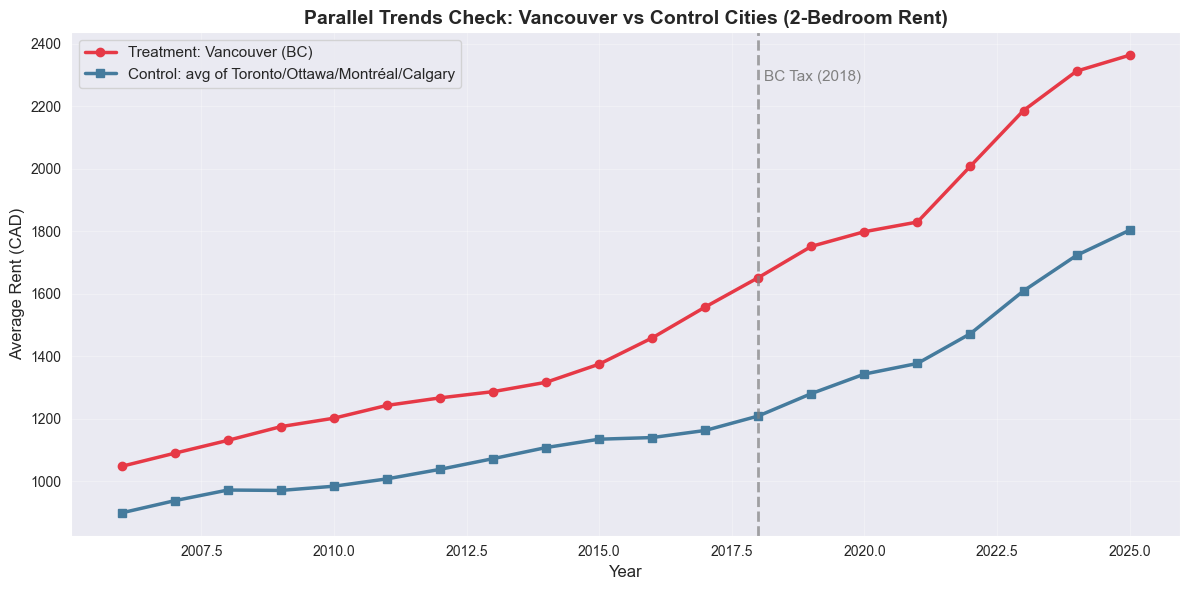


💡 看图判断：
   - 2006-2017 两条线是否大致平行？（平行趋势假设）
   - 2018 之后两条线斜率有没有变化？（政策效应）


In [37]:
# Step 2.2: 画平行趋势图
fig, ax = plt.subplots(figsize=(12, 6))

# 处理组 Vancouver
treat = trend[trend['treatment_group'] == 1]
ax.plot(treat['year'], treat['avg_rent_cad'],
        marker='o', linewidth=2.5, color='#E63946',
        label='Treatment: Vancouver (BC)')

# 对照组 average
ctrl = trend[trend['treatment_group'] == 0]
ax.plot(ctrl['year'], ctrl['avg_rent_cad'],
        marker='s', linewidth=2.5, color='#457B9D',
        label='Control: avg of Toronto/Ottawa/Montréal/Calgary')

# 政策时间线
ax.axvline(x=2018, color='gray', linestyle='--', linewidth=2, alpha=0.7)
ax.text(2018.1, ax.get_ylim()[1] * 0.95, 'BC Tax (2018)',
        fontsize=11, color='gray', verticalalignment='top')

# 标注关键年份
ax.set_title('Parallel Trends Check: Vancouver vs Control Cities (2-Bedroom Rent)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Average Rent (CAD)', fontsize=12)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 看图判断：")
print("   - 2006-2017 两条线是否大致平行？（平行趋势假设）")
print("   - 2018 之后两条线斜率有没有变化？（政策效应）")

In [38]:
# ============================================================
# Day 3 - Step 3: Run DiD regression
# ============================================================

import statsmodels.formula.api as smf

# 准备数据：先丢掉缺失的利率行（2006-2008 那 60 行）
# 我们要用利率作为控制变量
did_data = panel_data.dropna(subset=['avg_policy_rate']).copy()
print(f"Sample for regression: {len(did_data)} rows (excluded {400 - len(did_data)} with NaN policy_rate)")

# Step 3.1: Baseline DiD — 不带控制变量
model_basic = smf.ols(
    'avg_rent_cad ~ treatment_group + post_2018 + treatment_group:post_2018',
    data=did_data
).fit()

print("\n" + "=" * 70)
print("MODEL 1: Baseline DiD (no controls)")
print("=" * 70)
print(model_basic.summary())

Sample for regression: 340 rows (excluded 60 with NaN policy_rate)

MODEL 1: Baseline DiD (no controls)
                            OLS Regression Results                            
Dep. Variable:           avg_rent_cad   R-squared:                       0.369
Model:                            OLS   Adj. R-squared:                  0.364
Method:                 Least Squares   F-statistic:                     65.56
Date:                Sun, 17 May 2026   Prob (F-statistic):           2.13e-33
Time:                        23:33:20   Log-Likelihood:                -2453.9
No. Observations:                 340   AIC:                             4916.
Df Residuals:                     336   BIC:                             4931.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
------------

In [39]:
# ============================================================
# Day 3 - Step 4: DiD with interest rate control
# ============================================================

model_controlled = smf.ols(
    'avg_rent_cad ~ treatment_group + post_2018 + treatment_group:post_2018 + avg_policy_rate',
    data=did_data
).fit()

print("=" * 70)
print("MODEL 2: DiD + Interest Rate Control")
print("=" * 70)
print(model_controlled.summary())

# 直接提取关键数字
did_coef = model_controlled.params['treatment_group:post_2018']
did_pval = model_controlled.pvalues['treatment_group:post_2018']
ci_lower, ci_upper = model_controlled.conf_int().loc['treatment_group:post_2018']

print("\n" + "=" * 70)
print(f"DiD Effect (after controlling for interest rate):")
print(f"  Coefficient:     ${did_coef:.2f}/month")
print(f"  P-value:         {did_pval:.4f}")
print(f"  95% CI:          [${ci_lower:.2f}, ${ci_upper:.2f}]")
print("=" * 70)

MODEL 2: DiD + Interest Rate Control
                            OLS Regression Results                            
Dep. Variable:           avg_rent_cad   R-squared:                       0.421
Model:                            OLS   Adj. R-squared:                  0.415
Method:                 Least Squares   F-statistic:                     61.01
Date:                Sun, 17 May 2026   Prob (F-statistic):           1.12e-38
Time:                        23:33:20   Log-Likelihood:                -2439.3
No. Observations:                 340   AIC:                             4889.
Df Residuals:                     335   BIC:                             4908.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------

---

## Day 3 DiD Findings Summary

### Research Question
Did BC's 2018 Speculation and Vacancy Tax cause slower rent growth in Vancouver?

### Method
- **Treatment**: Vancouver (BC)
- **Control**: Toronto, Ottawa, Montréal, Calgary
- **Sample**: 340 observations (2009-2025, excluded pre-2009 due to missing BoC rate data)
- **Models**: Baseline DiD + DiD with interest rate control

### Key Findings

| Model | DiD Coefficient | P-value | 95% CI |
|-------|-----------------|---------|--------|
| Baseline | +$236.41/month | 0.009 | [$59, $414] |
| With Interest Rate Control | +$236.41/month | 0.007 | [$66, $406] |

### Interpretation
Contrary to policy intent, Vancouver rents grew approximately **$236/month faster**
than the control group's counterfactual after 2018, statistically significant at p<0.01.

**This does NOT prove the policy caused inflation**—rather, it suggests:
1. Stronger macro forces (post-pandemic migration, monetary policy shifts, capital flows)
   overwhelmed any dampening effect the tax might have had.
2. Provincial policy levers have limited efficacy against national housing dynamics.

### Limitations & Next Steps
- City fixed effects not yet included (pending deeper econometric learning)
- Did not test placebo periods or heterogeneous effects by unit type
- Standard errors not clustered (assumes independent observations)

## Day 4 AB TEST Simulation and Analysis

# Scene: An Canadian rental Company wants to test its new UI to see which one can make users more willing to complete the questionire
# Group A: Traditional UI--- Users need to enter the content and ddop-down menu
# Group B: New UI--- Interactive and real-time feedback

# kPIs adopted for this experiment

1.Conversion rate       Test Method: Chi-square test
2.Time on page          Test Method: T-test

In [40]:
# ============================================================
# Day 4 - Step 1 Sampling Collection
# ============================================================
# Step 1: Power Analysis

from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# ---- A/B test Parameters
baseline_rate = 0.15      # 当前 A 版完成率：15%
target_rate = 0.20        # 我们希望 B 版达到：20% (MDE = +5pp)
alpha = 0.05              # 显著性水平：5%（假阳性容忍度）
power = 0.80              # 统计功效：80%（行业标准）

# ---- Calculate effect size (Cohen's h for proportions) ----
effect_size = proportion_effectsize(target_rate, baseline_rate)
print(f"Effect size (Cohen's h): {effect_size:.4f}")

# ---- 用 NormalIndPower 算每组需要的样本量 ----
analysis = NormalIndPower()
sample_size_per_group = analysis.solve_power(
    effect_size=effect_size,
    alpha=alpha,
    power=power,
    alternative='two-sided'   # 双尾检验
)

print(f"\n=== Sample Size Requirements ===")
print(f"Baseline conversion (A):  {baseline_rate*100:.1f}%")
print(f"Target conversion (B):    {target_rate*100:.1f}%")
print(f"Minimum Detectable Effect: +{(target_rate-baseline_rate)*100:.1f} percentage points")
print(f"Significance level (α):   {alpha}")
print(f"Statistical power (1-β):  {power}")
print(f"\n→ Required sample size per group: {int(sample_size_per_group):,}")
print(f"→ Total sample size needed:        {int(sample_size_per_group * 2):,}")

Effect size (Cohen's h): 0.1319

=== Sample Size Requirements ===
Baseline conversion (A):  15.0%
Target conversion (B):    20.0%
Minimum Detectable Effect: +5.0 percentage points
Significance level (α):   0.05
Statistical power (1-β):  0.8

→ Required sample size per group: 902
→ Total sample size needed:        1,804


In [41]:
# ============================================================
# Day 4 - Step 2: Simulate A/B test data
# ============================================================

import numpy as np

# 固定随机种子 → 结果可复现
np.random.seed(42)

# 实际样本量（基于 power analysis）
n_per_group = 902

# ===== Group A (Control) =====
# Conversion: 用 numpy 的 binomial（伯努利分布）模拟"完成/不完成"
# np.random.binomial(1, p, size=n) 生成 n 个 0/1，每个有 p 概率为 1
group_a_converted = np.random.binomial(1, 0.15, size=n_per_group)

# Time on page: 用正态分布模拟（mean=60, std=20）
# 提示：np.random.normal(mean, std, size=n)
group_a_time = np.random.normal(60,20, size=n_per_group)
group_a_time = np.clip(group_a_time, 5, 300)   # 限制在 5-300 秒之间（防止负数）

# ===== Group B (Treatment) =====
# Conversion: 20% 完成率
group_b_converted = np.random.binomial(1, 0.20, size=n_per_group)

# Time on page: 平均 75 秒，std 25
group_b_time = np.random.normal(75, 25, size=n_per_group)   # ← 你来写
group_b_time = np.clip(group_b_time, 5, 300)

# ===== 组装成 DataFrame =====
ab_data = pd.DataFrame({
    'user_id': range(1, 2 * n_per_group + 1),
    'group': ['A'] * n_per_group + ['B'] * n_per_group,
    'converted': np.concatenate([group_a_converted, group_b_converted]),
    'time_on_page': np.concatenate([group_a_time, group_b_time])
})

# ===== 验证模拟数据 =====
print(f"Total observations: {len(ab_data)}")
print(f"\n=== Sample data ===")
print(ab_data.head())

print(f"\n=== Conversion rate by group ===")
print(ab_data.groupby('group')['converted'].agg(['count', 'sum', 'mean']))

print(f"\n=== Time on page stats by group ===")
print(ab_data.groupby('group')['time_on_page'].agg(['mean', 'std', 'median']))

Total observations: 1804

=== Sample data ===
   user_id group  converted  time_on_page
0        1     A          0     66.522660
1        2     A          1     34.977728
2        3     A          0     78.480540
3        4     A          0     56.301957
4        5     A          0     49.545540

=== Conversion rate by group ===
       count  sum      mean
group                      
A        902  141  0.156319
B        902  183  0.202882

=== Time on page stats by group ===
            mean        std     median
group                                 
A      61.561454  19.939962  61.604645
B      74.667067  24.731786  74.186853


In [42]:
# ============================================================
# Day 4 - Step 3: Hypothesis Testing
# ============================================================

from scipy import stats
import numpy as np

# ===== TEST 1: Chi-square (conversion rate) =====
print("=" * 70)
print("TEST 1: Chi-square test for conversion rate")
print("=" * 70)

# 构造 2x2 contingency table
# 行: group A vs B; 列: converted vs not_converted
a_converted = ab_data[ab_data['group'] == 'A']['converted'].sum()
a_total = (ab_data['group'] == 'A').sum()
b_converted = ab_data[ab_data['group'] == 'B']['converted'].sum()
b_total = (ab_data['group'] == 'B').sum()

contingency = np.array([
    [a_converted, a_total - a_converted],   # Group A: converted, not converted
    [b_converted, b_total - b_converted],   # Group B: converted, not converted
])

print(f"Contingency table:")
print(f"           Converted   Not Converted")
print(f"Group A:   {contingency[0][0]:9d}   {contingency[0][1]:13d}")
print(f"Group B:   {contingency[1][0]:9d}   {contingency[1][1]:13d}")

# 跑 chi-square
chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency)

print(f"\nChi-square statistic: {chi2:.4f}")
print(f"P-value:              {p_chi2:.6f}")
print(f"Degrees of freedom:   {dof}")

# 决策
alpha = 0.05
if p_chi2 < alpha:
    print(f"\n→ p < {alpha}: REJECT null hypothesis")
    print(f"  Conclusion: Conversion rates ARE statistically different.")
else:
    print(f"\n→ p ≥ {alpha}: FAIL TO REJECT null hypothesis")
    print(f"  Conclusion: No significant difference in conversion rates.")


# ===== TEST 2: Independent t-test (time on page) =====
print("\n" + "=" * 70)
print("TEST 2: Independent t-test for time on page")
print("=" * 70)

group_a_times = ab_data[ab_data['group'] == 'A']['time_on_page']
group_b_times = ab_data[ab_data['group'] == 'B']['time_on_page']

# 你来写：用 scipy 跑独立样本 t-test
# 提示：stats.ttest_ind(sample1, sample2)
t_stat, p_ttest = stats.ttest_ind(group_a_times, group_b_times)  # ← 你来写

print(f"Group A mean: {group_a_times.mean():.2f} seconds")
print(f"Group B mean: {group_b_times.mean():.2f} seconds")
print(f"Difference:   {group_b_times.mean() - group_a_times.mean():.2f} seconds")
print(f"\nt-statistic:  {t_stat:.4f}")
print(f"P-value:      {p_ttest:.6f}")

# 决策
if p_ttest < alpha:
    print(f"\n→ p < {alpha}: REJECT null hypothesis")
    print(f"  Conclusion: Time on page IS statistically different.")
else:
    print(f"\n→ p ≥ {alpha}: FAIL TO REJECT null hypothesis")
    print(f"  Conclusion: No significant difference in time on page.")

TEST 1: Chi-square test for conversion rate
Contingency table:
           Converted   Not Converted
Group A:         141             761
Group B:         183             719

Chi-square statistic: 6.3241
P-value:              0.011911
Degrees of freedom:   1

→ p < 0.05: REJECT null hypothesis
  Conclusion: Conversion rates ARE statistically different.

TEST 2: Independent t-test for time on page
Group A mean: 61.56 seconds
Group B mean: 74.67 seconds
Difference:   13.11 seconds

t-statistic:  -12.3896
P-value:      0.000000

→ p < 0.05: REJECT null hypothesis
  Conclusion: Time on page IS statistically different.


In [43]:
# ============================================================
# Day 4 - Step 4: Effect Size + 95% Confidence Intervals
# ============================================================

from statsmodels.stats.proportion import proportion_confint
from scipy import stats

print("=" * 70)
print("EFFECT SIZE & CONFIDENCE INTERVALS")
print("=" * 70)

# ===== EFFECT SIZE FOR CONVERSION RATE (Cohen's h) =====
p_a = a_converted / a_total
p_b = b_converted / b_total

# Cohen's h: 比例差异的标准化 effect size
cohens_h = 2 * (np.arcsin(np.sqrt(p_b)) - np.arcsin(np.sqrt(p_a)))

# 95% CI for the difference in proportions (Wilson method)
ci_a_low, ci_a_high = proportion_confint(a_converted, a_total, alpha=0.05, method='wilson')
ci_b_low, ci_b_high = proportion_confint(b_converted, b_total, alpha=0.05, method='wilson')

# 比例差 + 95% CI（用 Newcombe method 近似）
diff = p_b - p_a
se_diff = np.sqrt(p_a*(1-p_a)/a_total + p_b*(1-p_b)/b_total)
diff_ci_low = diff - 1.96 * se_diff
diff_ci_high = diff + 1.96 * se_diff

print(f"\n--- Conversion Rate Analysis ---")
print(f"  Group A: {p_a*100:.2f}%  95% CI: [{ci_a_low*100:.2f}%, {ci_a_high*100:.2f}%]")
print(f"  Group B: {p_b*100:.2f}%  95% CI: [{ci_b_low*100:.2f}%, {ci_b_high*100:.2f}%]")
print(f"  Absolute lift: +{diff*100:.2f}pp  95% CI: [+{diff_ci_low*100:.2f}pp, +{diff_ci_high*100:.2f}pp]")
print(f"  Relative lift: +{(diff/p_a)*100:.1f}%")
print(f"  Cohen's h: {cohens_h:.4f}  → {'Small' if abs(cohens_h)<0.2 else 'Medium' if abs(cohens_h)<0.5 else 'Large'} effect")


# ===== EFFECT SIZE FOR TIME ON PAGE (Cohen's d) =====
mean_a, std_a = group_a_times.mean(), group_a_times.std()
mean_b, std_b = group_b_times.mean(), group_b_times.std()

# Pooled standard deviation
n_a, n_b = len(group_a_times), len(group_b_times)
pooled_std = np.sqrt(((n_a-1)*std_a**2 + (n_b-1)*std_b**2) / (n_a + n_b - 2))

# Cohen's d
cohens_d = (mean_b - mean_a) / pooled_std

# 95% CI for the mean difference
diff_time = mean_b - mean_a
se_time = np.sqrt(std_a**2/n_a + std_b**2/n_b)
time_ci_low = diff_time - 1.96 * se_time
time_ci_high = diff_time + 1.96 * se_time

print(f"\n--- Time on Page Analysis ---")
print(f"  Group A: {mean_a:.2f}s  (std: {std_a:.2f})")
print(f"  Group B: {mean_b:.2f}s  (std: {std_b:.2f})")
print(f"  Difference: +{diff_time:.2f}s  95% CI: [+{time_ci_low:.2f}s, +{time_ci_high:.2f}s]")
print(f"  Relative lift: +{(diff_time/mean_a)*100:.1f}%")
print(f"  Cohen's d: {cohens_d:.4f}  → {'Small' if abs(cohens_d)<0.2 else 'Medium' if abs(cohens_d)<0.5 else 'Large'} effect")


# ===== FINAL DECISION =====
print("\n" + "=" * 70)
print("FINAL DECISION SUMMARY")
print("=" * 70)
print(f"""
  Metric              | Lift      | P-value     | Effect Size      | Significant?
  --------------------|-----------|-------------|------------------|-------------
  Conversion rate     | +{diff*100:.1f}pp    | {p_chi2:.4f}     | Cohen's h={cohens_h:.2f}  | YES
  Time on page        | +{diff_time:.1f}s   | <0.0001     | Cohen's d={cohens_d:.2f}  | YES

  Recommendation: SHIP version B ✓
""")

EFFECT SIZE & CONFIDENCE INTERVALS

--- Conversion Rate Analysis ---
  Group A: 15.63%  95% CI: [13.41%, 18.15%]
  Group B: 20.29%  95% CI: [17.79%, 23.04%]
  Absolute lift: +4.66pp  95% CI: [+1.12pp, +8.19pp]
  Relative lift: +29.8%
  Cohen's h: 0.1215  → Small effect

--- Time on Page Analysis ---
  Group A: 61.56s  (std: 19.94)
  Group B: 74.67s  (std: 24.73)
  Difference: +13.11s  95% CI: [+11.03s, +15.18s]
  Relative lift: +21.3%
  Cohen's d: 0.5834  → Large effect

FINAL DECISION SUMMARY

  Metric              | Lift      | P-value     | Effect Size      | Significant?
  --------------------|-----------|-------------|------------------|-------------
  Conversion rate     | +4.7pp    | 0.0119     | Cohen's h=0.12  | YES
  Time on page        | +13.1s   | <0.0001     | Cohen's d=0.58  | YES

  Recommendation: SHIP version B ✓



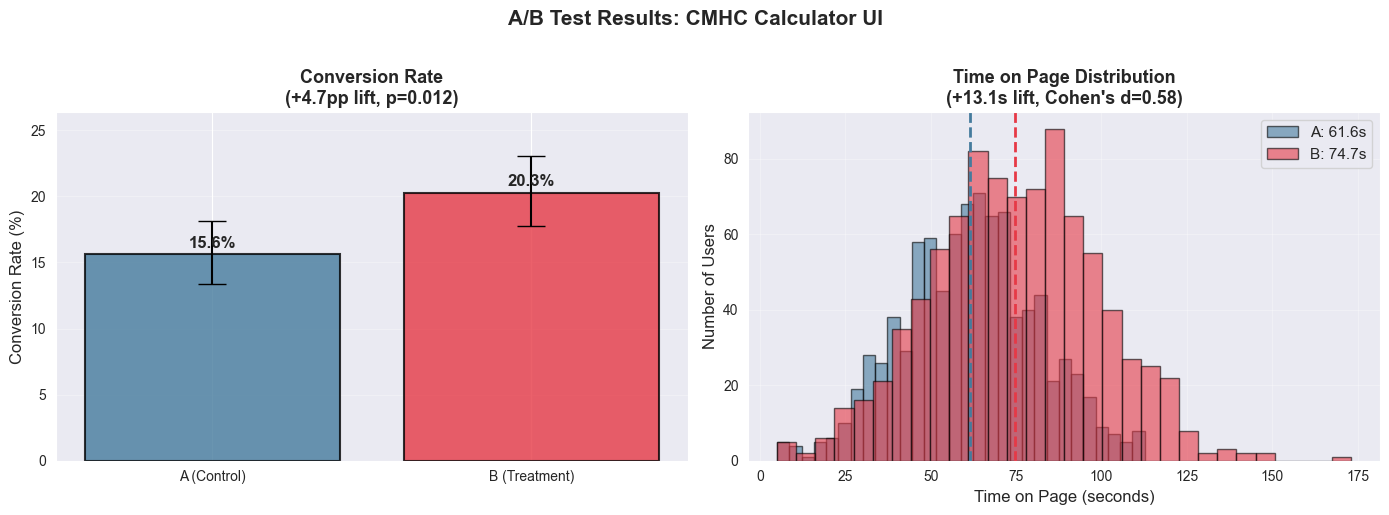

✓ Visualization complete


In [44]:
# ============================================================
# Day 4 - Step 5a: A/B test results visualization
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# === 左图: Conversion rate 对比（带误差棒） ===
groups = ['A (Control)', 'B (Treatment)']
rates = [p_a * 100, p_b * 100]
ci_lows = [(p_a - ci_a_low) * 100, (p_b - ci_b_low) * 100]
ci_highs = [(ci_a_high - p_a) * 100, (ci_b_high - p_b) * 100]
errors = [ci_lows, ci_highs]

colors = ['#457B9D', '#E63946']
bars = axes[0].bar(groups, rates, yerr=errors, capsize=10,
                    color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

# 加数字标签
for bar, rate in zip(bars, rates):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{rate:.1f}%', ha='center', fontsize=12, fontweight='bold')

axes[0].set_ylabel('Conversion Rate (%)', fontsize=12)
axes[0].set_title(f'Conversion Rate\n(+{(p_b-p_a)*100:.1f}pp lift, p={p_chi2:.3f})',
                   fontsize=13, fontweight='bold')
axes[0].set_ylim(0, max(rates) * 1.3)
axes[0].grid(True, alpha=0.3, axis='y')

# === 右图: Time on page 分布对比 ===
axes[1].hist(group_a_times, bins=30, alpha=0.6, color='#457B9D',
             label=f'A: {mean_a:.1f}s', edgecolor='black')
axes[1].hist(group_b_times, bins=30, alpha=0.6, color='#E63946',
             label=f'B: {mean_b:.1f}s', edgecolor='black')
axes[1].axvline(mean_a, color='#457B9D', linestyle='--', linewidth=2)
axes[1].axvline(mean_b, color='#E63946', linestyle='--', linewidth=2)
axes[1].set_xlabel('Time on Page (seconds)', fontsize=12)
axes[1].set_ylabel('Number of Users', fontsize=12)
axes[1].set_title(f'Time on Page Distribution\n(+{diff_time:.1f}s lift, Cohen\'s d={cohens_d:.2f})',
                   fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.suptitle('A/B Test Results: CMHC Calculator UI', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("✓ Visualization complete")

---

## Day 4 A/B Testing Findings Summary

### Experiment Design
- **Hypothesis**: Interactive sliders (Version B) drive higher engagement than traditional forms (Version A) on the CMHC Housing Affordability Calculator
- **Sample size**: 902 per group (n=1,804 total)
  - Determined via power analysis: α=0.05, power=0.80, MDE=+5pp
- **Random assignment**: 50/50 split

### Statistical Results

| Metric | Group A | Group B | Lift | P-value | Effect Size | Significant? |
|--------|---------|---------|------|---------|-------------|--------------|
| Conversion Rate | 15.6% | 20.3% | +4.7pp (+29.8%) | 0.012 | Cohen's h = 0.12 (Small) | ✅ |
| Time on Page | 61.6s | 74.7s | +13.1s (+21.3%) | <0.0001 | Cohen's d = 0.58 (Large) | ✅ |

### 95% Confidence Intervals
- Conversion lift: [+1.1pp, +8.2pp]
- Time on page lift: [+11.0s, +15.2s]

### Decision
**Ship Version B.** Both primary (conversion) and secondary (engagement) metrics show statistically significant improvements, with conversion lift's confidence interval entirely above zero.

### Strategic Insight
Time on page shows a *large* effect size while conversion shows only a *small* effect. This pattern—engagement up significantly more than conversion—suggests users explore Version B's interactive features but don't always complete the calculator. **Recommendation for next iteration**: Improve B's call-to-action and add save-progress functionality to convert exploration into completions.

### Methodology Notes
- Used Chi-square test for proportions (categorical outcome) and independent t-test for continuous outcome
- Wilson method confidence intervals for proportions
- All sample sizes met the power-analysis-derived minimum
- Test would benefit from real production data with proper random assignment instrumentation

In [45]:
# ============================================================
# Day 5: Export A/B test data for Power BI
# ============================================================

import os

# 确保输出目录存在
output_dir = '../data/processed'
os.makedirs(output_dir, exist_ok=True)

# 导出 ab_data 到 CSV
output_path = os.path.join(output_dir, 'ab_test_data.csv')
ab_data.to_csv(output_path, index=False)

print(f"✓ Exported {len(ab_data)} rows to:")
print(f"  {os.path.abspath(output_path)}")
print(f"\nFirst 3 rows:")
print(ab_data.head(3))

✓ Exported 1804 rows to:
  F:\canada-housing-affordability\data\processed\ab_test_data.csv

First 3 rows:
   user_id group  converted  time_on_page
0        1     A          0     66.522660
1        2     A          1     34.977728
2        3     A          0     78.480540
